# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

**A model is linear if the prediction is a linear combination of the parameters (b's). In other words, “linear” really refers to linearity in the coefficients, not necessarily linearity in the original input variables (e.g. b_1*sin(x) is linear w.r.t to the b_1).**

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)

**The interpretation of a dummy-variable coefficient depends on whether the model includes an intercept. If there is an intercept, one category must then be omitted. The dummy coefficient measures the difference between that category and the omitted reference group. If there is no intercept, each dummy coefficient represents the predicted outcome for that category itself rather than a difference from a baseline.** 

3. Can linear regression be used for classification? Explain why, or why not.

**Linear regression can be used in a crude way for classification by coding classes as 0 and 1 and thresholding the predictions, but it is generally not appropriate. This is because linear regression predicts continuous values, can give outputs below 0 or above 1, and does not properly model the probabilistic structure of categorical outcomes.**

4. What are signs that your linear model is over-fitting?

**A linear model is overfitting when it fits the training data much better than unseen data. A couple of signs are very low training error but much higher test error, "training R^2" increases while validation performance worsens, and unstable/very large coefficients. These signs suggest the model is capturing noise rather than the true relationship.**

5. Clearly explain multi-colinearity using the two-stage least squares technique.

**Multicollinearity occurs when one regressor is highly predictable from the other regressors. Using the two-stage least squares partialing-out idea, first regress x1​ on the other predictors and obtain the residual v, which is the part of x1 ​not explained by them. The coefficient on x1 ​in the main regression is identified only from this residual variation. If x1​ is highly collinear with the other predictors, then v is very small, meaning there is little unique information left to estimate its effect. This leads to unstable coefficients and large standard errors.**


6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

**To model nonlinear relationships, we can include nonlinear transformations of the predictors, such as x^2, x^3, log(x), or interaction terms. This lets linear regression capture curved relationships even though the model remains linear in the coefficients.**

7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**The intercept is the predicted value of y when all explanatory variables are zero, so it represents the model’s baseline prediction. A slope coefficient gives the change in predicted y associated with a one-unit increase in that variable, holding all other variables constant. For a dummy variable, the interpretation depends on the intercept. If the model includes an intercept, the dummy coefficient measures the difference between that category and the omitted reference category. If the model has no intercept, each dummy coefficient represents the predicted value for that category directly.**

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [ ]:
# Part 1

import pandas as pd

# Open The Data

df = pd.read_csv('./data/Q1_clean.csv')
print(df.head())

   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt


In [5]:
# Rename the column to remove the trailing space
df = df.rename(columns={"Neighbourhood ": "Neighbourhood"})

In [7]:
grouped = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
print(grouped, '\n')

most_expensive = grouped["Price"].idxmax()
print("Most expensive borough on average:", most_expensive)

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750 

Most expensive borough on average: Manhattan


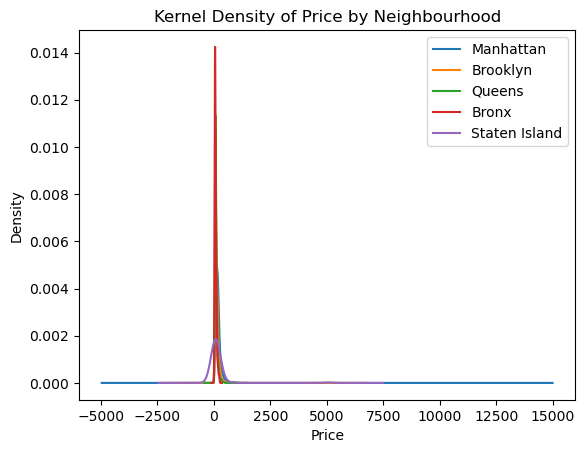

In [8]:
import matplotlib.pyplot as plt

for b in df["Neighbourhood"].dropna().unique():
    df.loc[df["Neighbourhood"] == b, "Price"].plot(
        kind="kde", label=b
    )

plt.xlabel("Price")
plt.title("Kernel Density of Price by Neighbourhood")
plt.legend()
plt.show()

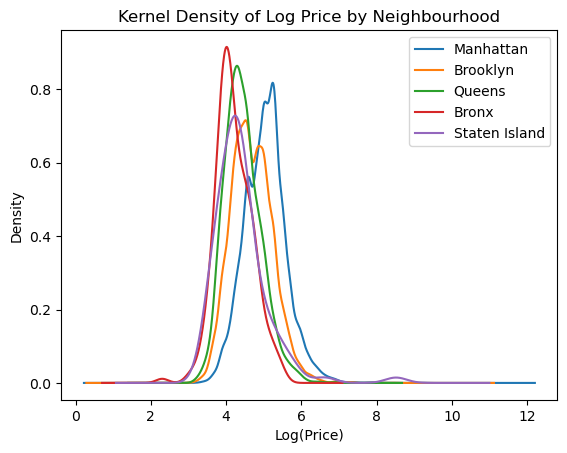

In [10]:
import numpy as np

df["log_price"] = np.log(df["Price"])

for b in df["Neighbourhood"].dropna().unique():
    df.loc[df["Neighbourhood"] == b, "log_price"].plot(
        kind="kde", label=b
    )

plt.xlabel("Log(Price)")
plt.title("Kernel Density of Log Price by Neighbourhood")
plt.legend()
plt.show()

**Response to 1.1:**

The most expensive borough on average is Manhattan which makes sense becuase it is the city center.

In [13]:
# Part 2

from sklearn.linear_model import LinearRegression

# target
y = df["Price"]

# dummy variables for borough
X_d = pd.get_dummies(df["Neighbourhood"], dtype=int)

# no intercept
reg = LinearRegression(fit_intercept=False).fit(X_d, y)

results = pd.DataFrame({
    "variable": reg.feature_names_in_,
    "coefficient": reg.coef_
})

print(results)

        variable  coefficient
0          Bronx    75.276498
1       Brooklyn   127.747378
2      Manhattan   183.664286
3         Queens    96.857233
4  Staten Island   146.166667


**1.2 Response:**

The coefficients match the average prices by borough from part 1. This occurs because the regression includes a dummy for every neighbourhood and omits the intercept. Essentially each coefficient is estimated as the sample mean of Price within that borough. In a regression of a continuous variable on a single categorical variable, the coefficients are the category means when all dummy variables are included and there is no intercept. If an intercept is included, the coefficients become differences relative to the omitted reference category.

In [ ]:
# Part 3

y = df["Price"]

# Drop one category automatically
X_d = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int)

# Do the regression 
reg = LinearRegression(fit_intercept=True).fit(X_d, y)

results = pd.DataFrame({
    "variable": ["Intercept"] + list(reg.feature_names_in_),
    "coefficient": [reg.intercept_] + list(reg.coef_)
})

print(results)

        variable  coefficient
0      Intercept    75.276498
1       Brooklyn    52.470881
2      Manhattan   108.387789
3         Queens    21.580735
4  Staten Island    70.890169


**Part 3 Response:**

When the intercept is included, one neighbourhood dummy must be omitted to avoid perfect multicollinearity. In this regression, Bronx is the omitted reference category. Therefore, the intercept is the average price in the Bronx, $75.28. Each dummy coefficient measures the difference in average price between that borough and the Bronx. For example, the Manhattan coefficient of 108.39 means that Manhattan listings are about $108.39 more expensive per night than Bronx listings on average. To recover the coefficients from part 2, you would add the intercept to each dummy coefficient, while the omitted category’s coefficient is simply the intercept itself.

In [ ]:
# Part 4

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define X and y
X = df[["Review Scores Rating", "Neighbourhood"]]
y = df["Price"]

# One-hot encode neighbourhood
X = pd.get_dummies(X, columns=["Neighbourhood"], drop_first=True, dtype=int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Fit model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R^2:", r2)
print("Test RMSE:", rmse)

# Coefficients
results = pd.DataFrame({
    "variable": ["Intercept"] + list(X_train.columns),
    "coefficient": [reg.intercept_] + list(reg.coef_)
})

print(results)

Test R^2: 0.03953256032941743
Test RMSE: 131.3987732306601
                      variable  coefficient
0                    Intercept   -34.479922
1         Review Scores Rating     1.200211
2       Neighbourhood_Brooklyn    51.490259
3      Neighbourhood_Manhattan   109.495005
4         Neighbourhood_Queens    20.970804
5  Neighbourhood_Staten Island    23.480513


**1.4 Response:**

On the test set, the model achieved an R2 of 0.0395 and an RMSE of 131.40. The coefficient on Review Scores Rating is 1.2002, meaning that, holding neighbourhood constant, a one-point increase in review score is associated with about a $1.20 increase in nightly price. Using Bronx as the omitted reference category, Manhattan has the largest neighbourhood coefficient (109.50), so it is the most expensive neighbourhood in this model.

In [ ]:
# Part 5:

X = df[["Review Scores Rating", "Neighbourhood", "Property Type"]]
X = pd.get_dummies(X, columns=["Neighbourhood", "Property Type"], drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Fit regression
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predict test data
y_pred = reg.predict(X_test)

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R^2:", r2)
print("Test RMSE:", rmse)

results = pd.DataFrame({
    "variable": ["Intercept"] + list(X_train.columns),
    "coefficient": [reg.intercept_] + list(reg.coef_)
})

print(results.sort_values("coefficient", ascending=False))

Test R^2: 0.0447843523091509
Test RMSE: 131.0390395671991
                         variable   coefficient
3         Neighbourhood_Manhattan  1.227119e+02
20        Property Type_Townhouse  8.559494e+01
13      Property Type_Condominium  8.155508e+01
18             Property Type_Loft  6.542737e+01
7              Property Type_Boat  6.194040e+01
2          Neighbourhood_Brooklyn  5.923892e+01
9             Property Type_Cabin  5.918468e+01
8          Property Type_Bungalow  5.669755e+01
15            Property Type_House  3.579226e+01
22            Property Type_Villa  3.348286e+01
4            Neighbourhood_Queens  2.680203e+01
5     Neighbourhood_Staten Island  1.617578e+01
21        Property Type_Treehouse  9.516747e+00
1            Review Scores Rating  1.190458e+00
16              Property Type_Hut -7.105427e-15
11           Property Type_Castle -1.421085e-14
19            Property Type_Other -1.649866e+00
10        Property Type_Camper/RV -1.976464e+01
12           Property Type_Cha

**Part 5 Response:**

On the test set, the model achieved an R2 of 0.0448 and an RMSE of 131.04. The coefficient on Review Scores Rating is 1.1905, meaning that, holding neighbourhood and property type constant, a one-point increase in review score is associated with about a $1.19 increase in nightly price. Among the property-type coefficients, Townhouse has the largest positive coefficient (85.59), so it is the most expensive kind of property to rent in this model, relative to the omitted baseline property type.

**Part 6 Response:**

The coefficient on Review Scores Rating changes from part 4 to part 5 because, in multiple regression, each coefficient is interpreted while holding the other included variables constant. In part 4, the coefficient measures the association between review score and price holding neighbourhood fixed. In part 5, it measures the association between review score and price holding both neighbourhood and property type fixed. Adding Property Type changes the set of controls, so the review-score coefficient is now based only on the variation in review scores that remains after accounting for both neighbourhood and property type.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [ ]:
# Part 1

# Read data
import pandas as pd

df = pd.read_csv('./data/cars_hw.csv')
print(df.head())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  


In [19]:
# Drop useless index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

         Make  Make_Year   Color  Body_Type  Mileage_Run No_of_Owners  \
0  Volkswagen       2017  silver      sedan        44611          1st   
1     Hyundai       2016     red  crossover        20305          1st   
2       Honda       2019   white        suv        29540          2nd   
3     Renault       2017  bronze  hatchback        35680          1st   
4     Hyundai       2017  orange  hatchback        25126          1st   

   Seating_Capacity Fuel_Type Transmission Transmission_Type   Price  
0                 5    diesel      7-Speed         Automatic  657000  
1                 5    petrol      5-Speed            Manual  682000  
2                 5    petrol      5-Speed            Manual  793000  
3                 5    petrol      5-Speed            Manual  414000  
4                 5    petrol      5-Speed            Manual  515000  
(976, 11)
Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run  

In [20]:
num_cols = ['Price', 'Make_Year', 'Mileage_Run', 'Seating_Capacity']
print(df[num_cols].describe())

              Price    Make_Year   Mileage_Run  Seating_Capacity
count  9.760000e+02   976.000000    976.000000        976.000000
mean   7.410195e+05  2016.963115  41571.195697          5.095287
std    3.673234e+05     2.818742  24390.995134          0.446224
min    1.880000e+05  2011.000000   1117.000000          4.000000
25%    4.757500e+05  2015.000000  22676.750000          5.000000
50%    6.665000e+05  2017.000000  37570.500000          5.000000
75%    8.830000e+05  2019.000000  57421.250000          5.000000
max    2.941000e+06  2022.000000  99495.000000          8.000000


In [ ]:
import numpy as np

# Take the log of price and milage as these value in the data are sparse
df['log_price'] = np.log(df['Price'])
df['log_mileage'] = np.log(df['Mileage_Run'])

In [ ]:
# Look at quantiles

q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Lower bound:", lower)
print("Upper bound:", upper)

# Outliers
print("Outliers:", ((df['Price'] < lower) | (df['Price'] > upper)).sum())

Lower bound: -135125.0
Upper bound: 1493875.0
Outliers: 54


In [23]:
df = df[df['Price'] <= upper].copy()

In [ ]:
q1_m = df['Mileage_Run'].quantile(0.25)
q3_m = df['Mileage_Run'].quantile(0.75)
iqr_m = q3_m - q1_m

lower_m = q1_m - 1.5 * iqr_m
upper_m = q3_m + 1.5 * iqr_m

# Check to make sure there are no more outliers
print("Mileage upper bound:", upper_m)
print("Mileage outliers:", ((df['Mileage_Run'] < lower_m) | (df['Mileage_Run'] > upper_m)).sum())
print(df.shape)

Mileage upper bound: 115025.5
Mileage outliers: 0
(922, 13)


**3.1 Response:**

I dropped the Unnamed: 0 column because it was just an index. I then examined the numeric variables and found that Price was strongly right-skewed and contained a number of extreme high-value observations. To address this, I created log_price and log_mileage as transformed versions of Price and Mileage_Run. Using the IQR rule, I identified 54 high-price outliers above 1,493,875 and removed them from the sample. After removing these observations, Mileage_Run no longer showed outliers under the same rule, so no additional trimming was needed.

In [28]:
# Part 2
import matplotlib.pyplot as plt

print(df['Price'].describe())

count    9.220000e+02
mean     6.768807e+05
std      2.563079e+05
min      1.880000e+05
25%      4.642500e+05
50%      6.470000e+05
75%      8.367500e+05
max      1.465000e+06
Name: Price, dtype: float64


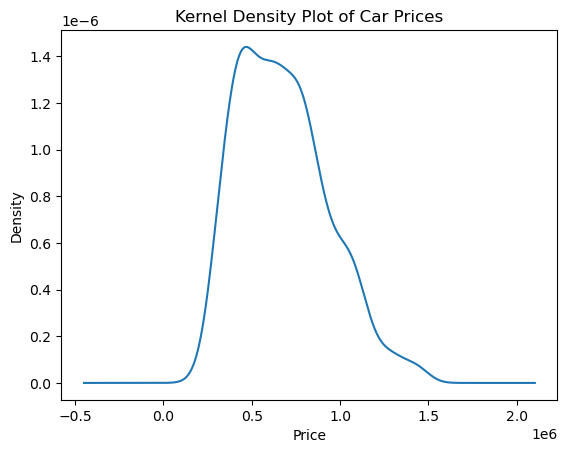

In [ ]:
# Kernal plot of just price

df['Price'].plot(kind='kde')
plt.xlabel('Price')
plt.title('Kernel Density Plot of Car Prices')
plt.show()

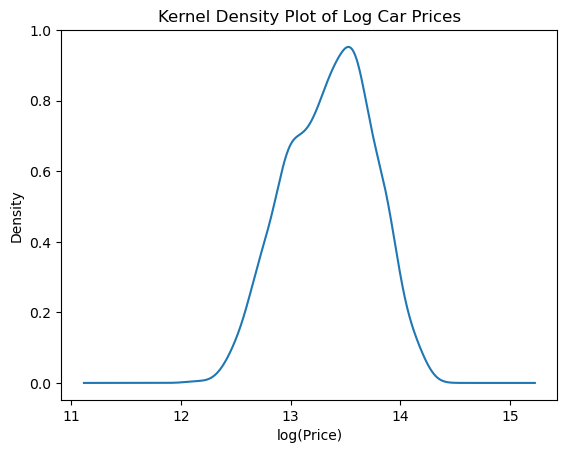

In [ ]:
# Kernal plot of log(price)

df['log_price'].plot(kind='kde')
plt.xlabel('log(Price)')
plt.title('Kernel Density Plot of Log Car Prices')
plt.show()

In [ ]:
# Summary table

make_summary = df.groupby('Make')['Price'].describe()
print(make_summary)

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           72.0  7.887222e+05  253474.460320   316000.0   580750.0   
Hyundai        304.0  6.884375e+05  273012.825123   248000.0   484750.0   
Jeep             1.0  1.290000e+06            NaN  1290000.0  1290000.0   
Kia              1.0  1.369000e+06            NaN  1369000.0  1369000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.625735e+05  214827.338943   287000.0   475000.0   
Skoda            4.0  6.8

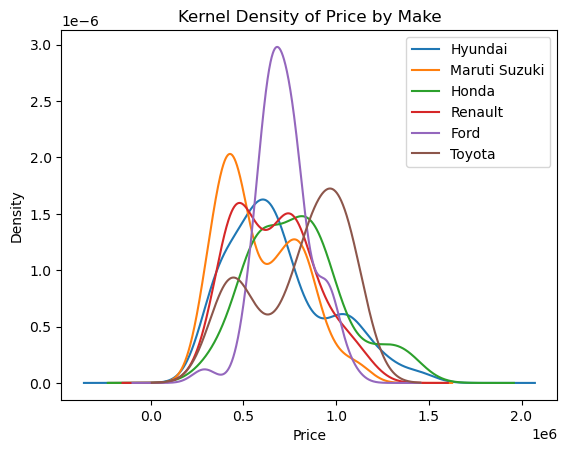

In [ ]:
# Take the top 6 since there are a lot of different car models
# Plotting all of the makes causes the plot to be really jumbled and not really interperatable 

counts = df['Make'].value_counts()
top_makes = counts[counts >= 2].head(6).index

for make in top_makes:
    df.loc[df['Make'] == make, 'Price'].plot(kind='kde', label=make)

plt.xlabel('Price')
plt.title('Kernel Density of Price by Make')
plt.legend()
plt.show()

**3.2 Response:**

The cleaned Price variable has a mean of about 676,881 and a median of 647,000, with prices ranging from 188,000 to 1,465,000. The kernel density plot shows that price is still somewhat right-skewed, although much less extreme after removing outliers. Most cars are concentrated in the mid-price range, and the kernel density plot of log-price is much more symmetric, suggesting that log-price is a better-scaled outcome for linear modeling. Grouping prices by Make shows that the highest mean prices belong to Kia, Jeep, and Mahindra, but Kia and Jeep each have only one observation, so those averages are not very reliable. Among brands with more substantial sample sizes, Mahindra, Toyota, Honda, and Tata appear to be the most expensive. The grouped kernel density plots also show that brands like Toyota and Honda tend to have price distributions shifted to the right, while Maruti Suzuki and Hyundai are concentrated at lower price levels.

In [ ]:
# Part 3

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=0)

print(train_df.shape)
print(test_df.shape)

(737, 13)
(185, 13)


In [ ]:
# Part 4:

from sklearn.metrics import r2_score, mean_squared_error

# Numeric-only model
num_vars = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']

# Define train and test for regression
X_train_num = train_df[num_vars]
X_test_num = test_df[num_vars]
y_train = train_df['Price']
y_test = test_df['Price']

# Conduct regression
reg_num = LinearRegression()
reg_num.fit(X_train_num, y_train)

# Predict the train and test
y_train_pred_num = reg_num.predict(X_train_num)
y_test_pred_num = reg_num.predict(X_test_num)

# Calculate metrics
r2_train_num = r2_score(y_train, y_train_pred_num)
rmse_train_num = np.sqrt(mean_squared_error(y_train, y_train_pred_num))

r2_test_num = r2_score(y_test, y_test_pred_num)
rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))

print("Numeric-only model")
print("Train R^2:", r2_train_num)
print("Train RMSE:", rmse_train_num)
print("Test R^2:", r2_test_num)
print("Test RMSE:", rmse_test_num)


Numeric-only model
Train R^2: 0.3576228437372383
Train RMSE: 203150.6546853782
Test R^2: 0.27960147043302996
Test RMSE: 226328.2047804537


In [ ]:
# Categorical-only model
cat_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners',
            'Fuel_Type', 'Transmission', 'Transmission_Type']

X_train_cat = pd.get_dummies(train_df[cat_vars], drop_first=True, dtype=int)
X_test_cat = pd.get_dummies(test_df[cat_vars], drop_first=True, dtype=int)

# Make sure test columns match train columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Conduct regression and fit
reg_cat = LinearRegression()
reg_cat.fit(X_train_cat, y_train)

#Make predcition on test (question did not ask to predict on train data)
y_test_pred_cat = reg_cat.predict(X_test_cat)

# Compute metrics
r2_test_cat = r2_score(y_test, y_test_pred_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

print("\nCategorical-only model")
print("Test R^2:", r2_test_cat)
print("Test RMSE:", rmse_test_cat)


Categorical-only model
Test R^2: 0.5205008133088183
Test RMSE: 184648.679949688


In [ ]:
# Combined model
X_train_all = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)

X_test_all = pd.concat([X_test_num.reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

# Regression here
reg_all = LinearRegression()
reg_all.fit(X_train_all, y_train)

# Predict
y_test_pred_all = reg_all.predict(X_test_all)

# Compute scores
r2_test_all = r2_score(y_test, y_test_pred_all)
rmse_test_all = np.sqrt(mean_squared_error(y_test, y_test_pred_all))

print("\nCombined model")
print("Test R^2:", r2_test_all)
print("Test RMSE:", rmse_test_all)


Combined model
Test R^2: 0.7192097188559337
Test RMSE: 141300.37214098545


In [ ]:
# Printing a summary here:

print("\nComparison on test set")
print("Numeric-only R^2:", r2_test_num, ", RMSE:", rmse_test_num)
print("Categorical-only R^2:", r2_test_cat, ", RMSE:", rmse_test_cat)
print("Combined R^2:", r2_test_all, ", RMSE:", rmse_test_all)

print("\nImprovement of combined over numeric-only")
print("Delta R^2:", r2_test_all - r2_test_num)
print("Delta RMSE:", rmse_test_num - rmse_test_all)

print("\nImprovement of combined over categorical-only")
print("Delta R^2:", r2_test_all - r2_test_cat)
print("Delta RMSE:", rmse_test_cat - rmse_test_all)


Comparison on test set
Numeric-only R^2: 0.27960147043302996 , RMSE: 226328.2047804537
Categorical-only R^2: 0.5205008133088183 , RMSE: 184648.679949688
Combined R^2: 0.7192097188559337 , RMSE: 141300.37214098545

Improvement of combined over numeric-only
Delta R^2: 0.4396082484229037
Delta RMSE: 85027.83263946825

Improvement of combined over categorical-only
Delta R^2: 0.1987089055471154
Delta RMSE: 43348.30780870255


**3.4 Response:** 

On the test set, the numeric-only model achieved an R2 of 0.2796 and an RMSE of 226,328, while the categorical-only model achieved an R2 of 0.5205 and an RMSE of 184,649. Thus, the categorical-only model performed better than the numeric-only model. The combined model performed best overall, with a test-set R2 of 0.7192 and an RMSE of 141,300. Relative to the numeric-only model, the combined model improved R2 by 0.4396 and reduced RMSE by about 85,028. Relative to the categorical-only model, it improved R2 by 0.1987 and reduced RMSE by about 43,348. This indicates that both numeric and categorical features matter for predicting car prices, and that the joint model captures substantially more information than either model alone.

In [ ]:
# Part 5:
from sklearn.preprocessing import PolynomialFeatures

num_vars = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']

X_train_num = train_df[num_vars]
X_test_num = test_df[num_vars]
y_train = train_df['Price']
y_test = test_df['Price']

results = [] # Keep track of scores here

for d in range(1, 28): # Loop to vary the degress of polynomial 
    poly = PolynomialFeatures(degree=d, include_bias=False)
    
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)
    
    # Regression here
    reg = LinearRegression()
    reg.fit(X_train_poly, y_train)
    
    # Prediction here
    y_train_pred = reg.predict(X_train_poly)
    y_test_pred = reg.predict(X_test_poly)
    
    # Compute metrics
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    results.append([d, r2_train, rmse_train, r2_test, rmse_test])

# Print a summary of the results
poly_results = pd.DataFrame(
    results,
    columns=['degree', 'train_r2', 'train_rmse', 'test_r2', 'test_rmse']
)

print(poly_results)


    degree  train_r2     train_rmse   test_r2      test_rmse
0        1  0.357623  203150.654685  0.279601  226328.204780
1        2  0.393529  197391.374278  0.319303  220003.248467
2        3  0.387064  198440.639362  0.311199  221309.092390
3        4  0.390199  197932.581557  0.309011  221660.283053
4        5  0.388009  198287.608228  0.298541  223333.325440
5        6  0.387498  198370.472935  0.290128  224668.548046
6        7  0.246240  220059.324988  0.189360  240085.716420
7        8  0.213703  224758.723709  0.182850  241047.776111
8        9  0.194377  227503.981235  0.158665  244588.891556
9       10  0.170343  230872.583190  0.143929  246721.609391
10      11  0.154168  233112.373856  0.127856  249027.015726
11      12  0.140763  234952.218757  0.112320  251235.169406
12      13  0.129174  236531.380161  0.097680  253298.493194
13      14  0.108919  239266.445045  0.092031  254090.189161
14      15  0.099197  240568.112376  0.079716  255807.427166
15      16  0.091252  24

**3.5 Response:**

Test-set performance improved slightly from degree 1 to degree 2, where the model achieved its best performance with R2 = 0.3193 and RMSE = 220,003. After degree 2, test R2 steadily declined and test RMSE increased, indicating overfitting as model complexity increased. The test R2 first became negative at degree 27, meaning the model was then performing worse than a mean-only prediction. Compared with the best model from part 4, which had R2 =0.7192 and RMSE = 141,300, the best polynomial numeric-only model performed substantially worse. Its R2 was lower by about 0.400 and its RMSE was higher by about 78,703. This suggests that the categorical variables contain much more useful information for predicting car prices than polynomial expansion of the numeric variables alone.

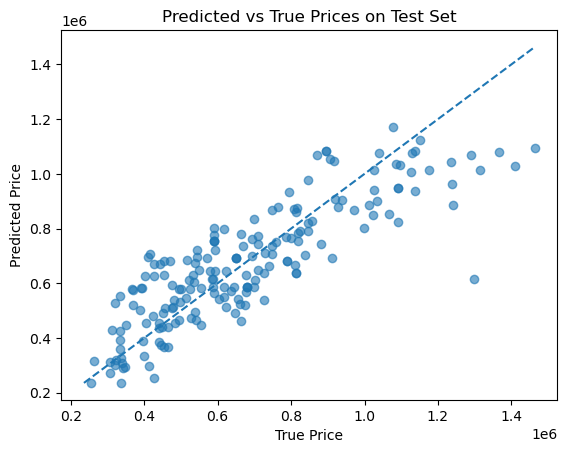

In [ ]:
# Part 6

import matplotlib.pyplot as plt
import pandas as pd

# Predicted values on test set
y_test_pred_all = reg_all.predict(X_test_all)

# Scatter plot for predicted vs true
plt.scatter(y_test, y_test_pred_all, alpha=0.6)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Prices on Test Set")

# 45 degree line
min_val = min(y_test.min(), y_test_pred_all.min())
max_val = max(y_test.max(), y_test_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

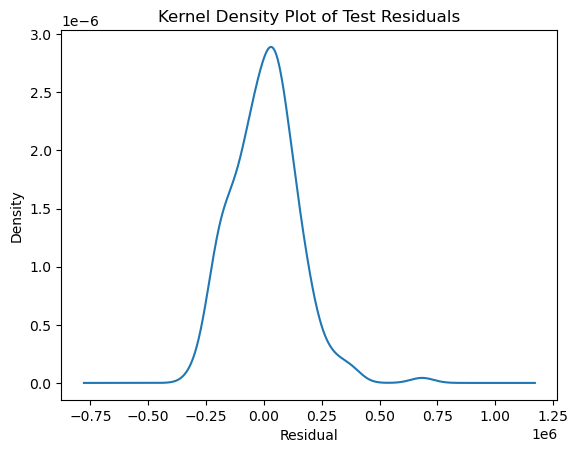

In [ ]:
# Compute the residuals
residuals = y_test - y_test_pred_all

# KDE plot of residuals
pd.Series(residuals).plot(kind='kde')
plt.xlabel("Residual")
plt.title("Kernel Density Plot of Test Residuals")
plt.show()

**3.6 Response:**

I used the combined model from part 4, since it had the strongest test-set performance. The scatter plot of predicted versus true prices shows that the predictions line up reasonably well with the 45-degree line, so the model captures much of the underlying variation in car prices. However, the points are not perfectly concentrated on the diagonal, and the model appears to underpredict some of the most expensive cars. The kernel density plot of the test residuals is centered approximately around zero and is roughly bell-shaped, which suggests that the model is not strongly biased overall. At the same time, the residual distribution shows some asymmetry and a longer right tail, indicating that a subset of cars are underpredicted by a noticeable amount. A major strength of the model is that it combines both numeric and categorical information and achieves the best predictive performance so far. It explains a substantial share of the variation in prices and produces predictions that generally track the true values well. A weakness is that prediction errors are still fairly large in dollar terms, especially for high-priced vehicles, and the model may miss nonlinearities or interaction effects that matter for more unusual cars.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

![My image]((4_1).png)

![My image]((4_2).png)

![My image]((4_3).png)

![My image]((4_4).png)

![My image]((4_5).png)